<a href="https://colab.research.google.com/github/Kylalala13/Visi-Komputer/blob/main/Jobsheet_2_Klasifikasi_gambar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Praktikum 1: Memulai Klasifikasi Gambar dengan Dataset Sederhana

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


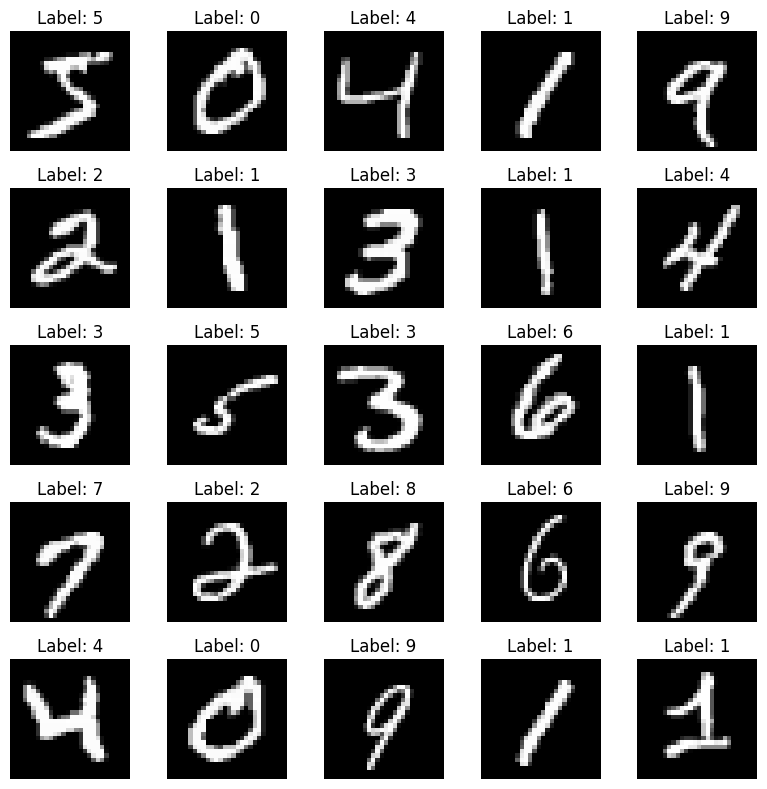

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist

# Load data
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Tampilkan contoh (Tugas kecil: diubah ke range(25))
plt.figure(figsize=(8, 8))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

Praktikum 2: lasifikasi Gambar dengan Model Machine Learning Tradisional

In [ ]:
from sklearn import svm
from sklearn.metrics import accuracy_score

# Flatten
x_train_flat = x_train.reshape(len(x_train), -1) / 255.0
x_test_flat = x_test.reshape(len(x_test), -1) / 255.0

# SVM
clf = svm.SVC(kernel='linear', gamma='scale')
clf.fit(x_train_flat[:5000], y_train[:5000])
y_pred = clf.predict(x_test_flat)

print("Akurasi:", accuracy_score(y_test, y_pred))

Akurasi: 0.9101


Ubah kernel dari linear menjadi rbf

In [ ]:
from sklearn import svm
from sklearn.metrics import accuracy_score

# Flatten & Normalisasi
x_train_flat = x_train.reshape(len(x_train), -1) / 255.0
x_test_flat = x_test.reshape(len(x_test), -1) / 255.0

# Train SVM dengan kernel RBF (Jawaban Tugas Kecil: diubah ke RBF dengan probability=True untuk penugasan)
clf = svm.SVC(kernel='rbf', gamma='scale', probability=True)
clf.fit(x_train_flat[:5000], y_train[:5000])

y_pred = clf.predict(x_test_flat)
print("Akurasi SVM:", accuracy_score(y_test, y_pred))

Akurasi SVM: 0.9513


Praktikum 3: Membangun CNN Sederhana

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 56s 32ms/step - accuracy: 0.9514 - loss: 0.1571 - val_accuracy: 0.9852 - val_loss: 0.0464
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 81s 32ms/step - accuracy: 0.9843 - loss: 0.0508 - val_accuracy: 0.9867 - val_loss: 0.0458
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 81s 31ms/step - accuracy: 0.9896 - loss: 0.0348 - val_accuracy: 0.9893 - val_loss: 0.0329
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 52s 31ms/step - accuracy: 0.9917 - loss: 0.0262 - val_accuracy: 0.9912 - val_loss: 0.0295
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 83s 31ms/step - accuracy: 0.9940 - loss: 0.0190 - val_accuracy: 0.9903 - val_loss: 0.0342


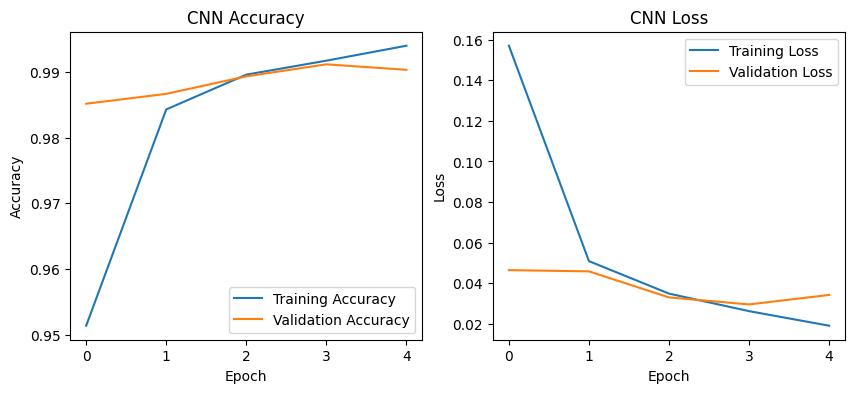

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

x_train_cnn = x_train.reshape(-1, 28, 28, 1) / 255.0
x_test_cnn = x_test.reshape(-1, 28, 28, 1) / 255.0

# Arsitektur dengan penambahan 1 lapisan Conv2D ekstra (Tugas kecil D3)
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'), # Lapisan Conv2D tambahan
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(x_train_cnn, y_train, epochs=5, validation_split=0.1)

# Plot history
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('CNN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('CNN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

Praktikum 4: Eksperimen dengan Dataset Lebih Kompleks (CIFAR-10)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1024s 6us/step
Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 68s 47ms/step - accuracy: 0.4267 - loss: 1.5742 - val_accuracy: 0.5348 - val_loss: 1.2902
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 64s 46ms/step - accuracy: 0.5539 - loss: 1.2557 - val_accuracy: 0.6038 - val_loss: 1.1195
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 64s 45ms/step - accuracy: 0.5947 - loss: 1.1417 - val_accuracy: 0.6474 - val_loss: 1.0181
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 63s 45ms/step - accuracy: 0.6271 - loss: 1.0716 - val_accuracy: 0.6742 - val_loss: 0.9520
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 63s 45ms/step - accuracy: 0.6410 - loss: 1.0179 - val_accuracy: 0.6750 - val_loss: 0.9477
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 62s 44ms/step - accuracy: 0.6598 - loss: 0.9672 - val_accuracy: 0.6920 - val_loss: 0.8888
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 83s 45ms/step - accuracy: 0.6768 - loss: 0.9223 - val_accuracy: 0.6986 - val_loss: 0.8639
Epoch 8/10
1407/1407

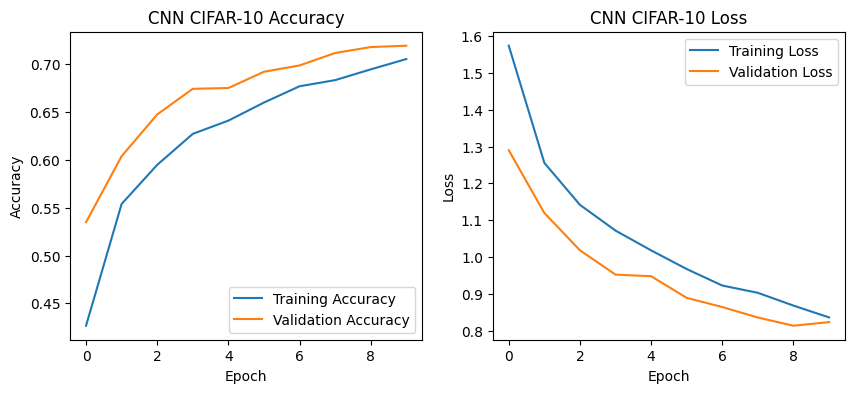

In [ ]:
from tensorflow.keras.datasets import cifar10
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

(x_train_c10, y_train_c10), (x_test_c10, y_test_c10) = cifar10.load_data()
x_train_c10, x_test_c10 = x_train_c10 / 255.0, x_test_c10 / 255.0

# Tambahkan Dropout (0.5) (Tugas kecil D4)
model_c10 = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dropout(0.5), # Dropout layer
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model_c10.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

history_c10 = model_c10.fit(x_train_c10, y_train_c10, epochs=10, validation_split=0.1)

# Plot history
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history_c10.history['accuracy'], label='Training Accuracy')
plt.plot(history_c10.history['val_accuracy'], label='Validation Accuracy')
plt.title('CNN CIFAR-10 Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_c10.history['loss'], label='Training Loss')
plt.plot(history_c10.history['val_loss'], label='Validation Loss')
plt.title('CNN CIFAR-10 Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

Praktikum 5: Transfer Learning dengan Model Pra-Latih

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Epoch 1/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 795s 564ms/step - accuracy: 0.5641 - loss: 1.2419 - val_accuracy: 0.6236 - val_loss: 1.0620
Epoch 2/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 774s 550ms/step - accuracy: 0.6311 - loss: 1.0491 - val_accuracy: 0.6216 - val_loss: 1.0539
Epoch 3/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 773s 549ms/step - accuracy: 0.6590 - loss: 0.9689 - val_accuracy: 0.6442 - val_loss: 0.9992
Epoch 4/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 801s 549ms/step - accuracy: 0.6761 - loss: 0.9255 - val_accuracy: 0.6422 - val_loss: 0.9987
Epoch 5/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 771s 548ms/step - accuracy: 0.6870 - loss: 0.8834 - val_accuracy: 0.6468 - val_loss: 1.0093


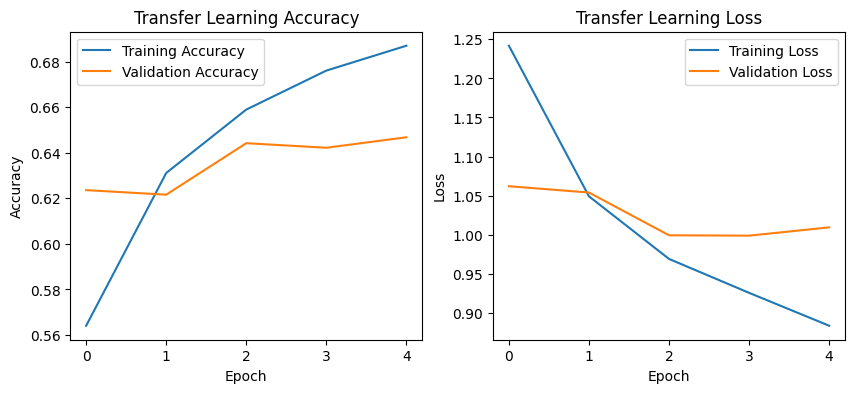

In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

base_model = VGG16(weights='imagenet', include_top=False, input_shape=(32, 32, 3))

# Unfreeze 2 lapisan terakhir (Tugas kecil D5: Fine-tuning)
base_model.trainable = True
for layer in base_model.layers[:-2]:
    layer.trainable = False

model_tl = models.Sequential([
    base_model,
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model_tl.compile(optimizer='adam',
                 loss='sparse_categorical_crossentropy',
                 metrics=['accuracy'])

history_tl = model_tl.fit(x_train_c10, y_train_c10, epochs=5, validation_split=0.1)

# Plot history
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history_tl.history['accuracy'], label='Training Accuracy')
plt.plot(history_tl.history['val_accuracy'], label='Validation Accuracy')
plt.title('Transfer Learning Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_tl.history['loss'], label='Training Loss')
plt.plot(history_tl.history['val_loss'], label='Validation Loss')
plt.title('Transfer Learning Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

Praktikum 6: Evaluasi dengan Confusion Matrix dan Metrik Lain

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.99      0.99      0.99      1032
           3       0.98      0.99      0.99      1010
           4       0.99      1.00      0.99       982
           5       0.98      0.99      0.99       892
           6       0.99      0.99      0.99       958
           7       0.98      0.99      0.99      1028
           8       0.99      0.99      0.99       974
           9       1.00      0.98      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



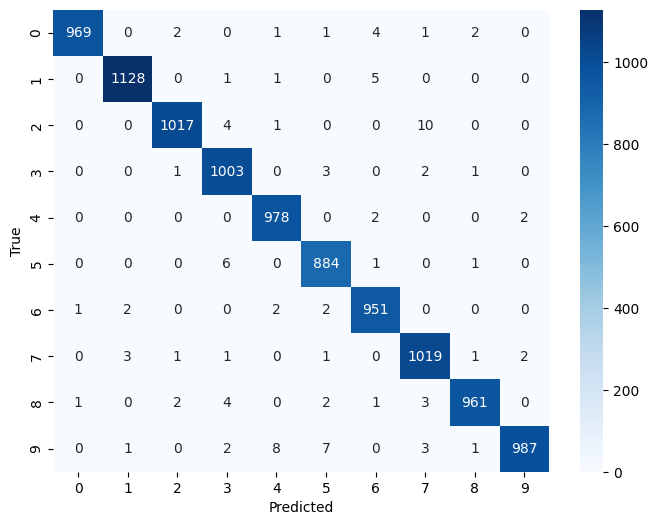

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Evaluasi model CNN D3 pada test set MNIST
y_pred = model.predict(x_test_cnn).argmax(axis=1)

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

Penugasan

Saving WhatsApp Image 2026-09-14 at 13.17.07.jpeg to WhatsApp Image 2026-09-14 at 13.17.07.jpeg


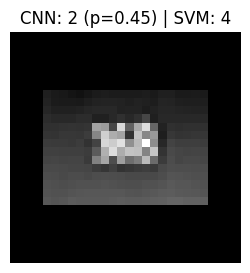


--- Rekap Hasil Prediksi ---
File: WhatsApp Image 2026-09-14 at 13.17.07.jpeg
  └─ Prediksi CNN : 2 (Probabilitas: 0.452)
  └─ Prediksi SVM : 4 (Probabilitas: 0.901)


In [ ]:
from google.colab import files
import numpy as np
from PIL import Image, ImageOps
import matplotlib.pyplot as plt

# 1) Upload Gambar
uploaded = files.upload()

# 2) Fungsi Preprocessing standar Jobsheet
def preprocess_to_mnist_28x28(img_pil):
    img = img_pil.convert('L')
    img = ImageOps.autocontrast(img)
    arr = np.array(img).astype(np.uint8)

    if arr.mean() > 127:
        img = ImageOps.invert(img)
        arr = np.array(img)

    thr = np.mean(arr) * 0.8
    mask = arr > thr
    if mask.any():
        ys, xs = np.where(mask)
        img = img.crop((xs.min(), ys.min(), xs.max() + 1, ys.max() + 1))

    img.thumbnail((20, 20), Image.Resampling.LANCZOS)
    canvas = Image.new('L', (28, 28), color=0)
    canvas.paste(img, ((28 - img.size[0]) // 2, (28 - img.size[1]) // 2))

    arr = np.array(canvas).astype('float32') / 255.0
    arr_cnn = arr[..., None]
    return canvas, arr_cnn, arr.reshape(1, -1)

# 3) Eksekusi Prediksi (Pilihan A & B)
results_cnn = []
results_svm = []

for fname in uploaded.keys():
    img_pil = Image.open(fname)
    disp, x_cnn, x_flat = preprocess_to_mnist_28x28(img_pil)

    # Prediksi CNN (D3)
    x_batch = np.expand_dims(x_cnn, axis=0)
    probs_cnn = model.predict(x_batch, verbose=0)[0]
    pred_cnn = int(np.argmax(probs_cnn))
    conf_cnn = float(np.max(probs_cnn))
    results_cnn.append((fname, pred_cnn, conf_cnn))

    # Prediksi SVM (D2)
    pred_svm = int(clf.predict(x_flat)[0])
    conf_svm = float(np.max(clf.predict_proba(x_flat))) if hasattr(clf, "predict_proba") else None
    results_svm.append((fname, pred_svm, conf_svm))

    # Visualisasi
    plt.figure(figsize=(3, 3))
    plt.imshow(disp, cmap='gray')
    plt.title(f"CNN: {pred_cnn} (p={conf_cnn:.2f}) | SVM: {pred_svm}")
    plt.axis('off')
    plt.show()

# Rekap Hasil
print("\n--- Rekap Hasil Prediksi ---")
for r_cnn, r_svm in zip(results_cnn, results_svm):
    print(f"File: {r_cnn[0]}")
    print(f"  └─ Prediksi CNN : {r_cnn[1]} (Probabilitas: {r_cnn[2]:.3f})")
    print(f"  └─ Prediksi SVM : {r_svm[1]}" + (f" (Probabilitas: {r_svm[2]:.3f})" if r_svm[2] else ""))